# Усреднённая оценка моделей по всем SKU

В предыдущем ноутбуке (`01_model_training_and_evaluation.ipynb`) метрики считались на одной паре
товар+магазин. Здесь тот же пайплайн (train/test split по времени, линейная регрессия,
LightGBM с подбором гиперпараметров) прогоняется **по всем парам товар×магазин** и метрики
усредняются — чтобы исключить случайность одного нетипичного SKU.


In [1]:
import sys
from pathlib import Path
import subprocess
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from lightgbm import LGBMRegressor
from scipy.stats import randint, uniform

warnings.filterwarnings("ignore")

ROOT = Path.cwd()
if not (ROOT / "model").exists():
    ROOT = ROOT.parent
sys.path.append(str(ROOT))

DATA_PATH = ROOT / "data" / "sales_history.csv"
if not DATA_PATH.exists():
    subprocess.run([sys.executable, str(ROOT / "generator" / "generate_data.py")], check=True)

pd.set_option("display.max_columns", 30)
RANDOM_STATE = 42


## Данные и список SKU

In [2]:
df = pd.read_csv(DATA_PATH, parse_dates=["date"])
entities = df[["product", "store_id"]].drop_duplicates().sort_values(["product", "store_id"]).reset_index(drop=True)
print(f"Всего пар товар×магазин: {len(entities)}")
entities.head()


Всего пар товар×магазин: 25


,product,store_id
0,Кофе,1
1,Кофе,2
2,Кофе,3
3,Кофе,4
4,Кофе,5


## Функции пайплайна

Те же шаги, что в ноутбуке 01, но обёрнутые в функции, чтобы прогнать по каждому SKU:
1. Очистка (без OOS, без нулевых продаж)
2. Split по времени 80/20
3. Линейная регрессия — baseline
4. Признаки для LightGBM + `RandomizedSearchCV` с `TimeSeriesSplit` (быстрее GridSearch на 25 прогонах)
5. Метрики на тесте


In [3]:
FEATURES = ["our_price", "competitor_price", "price_gap", "doy_sin", "doy_cos",
            "dow", "month", "sales_lag1", "sales_lag7", "sales_roll7"]


def regression_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    mape = float(np.mean(np.abs((y_true - y_pred) / np.clip(y_true, 1, None))) * 100)
    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "MAPE_%": mape, "R2": r2}


def build_features(frame: pd.DataFrame) -> pd.DataFrame:
    work = frame.sort_values("date").copy()
    doy = work["date"].dt.dayofyear.astype(float)
    work["doy_sin"] = np.sin(2 * np.pi * doy / 365.0)
    work["doy_cos"] = np.cos(2 * np.pi * doy / 365.0)
    work["dow"] = work["date"].dt.dayofweek.astype(int)
    work["month"] = work["date"].dt.month.astype(int)
    work["price_gap"] = work["our_price"] - work["competitor_price"]
    work["sales_lag1"] = work["sales"].shift(1)
    work["sales_lag7"] = work["sales"].shift(7)
    work["sales_roll7"] = work["sales"].shift(1).rolling(7, min_periods=2).mean()
    return work


def evaluate_entity(entity_df: pd.DataFrame) -> dict | None:
    clean = entity_df[~entity_df["is_oos"].astype(str).str.lower().isin(["true", "1"])]
    clean = clean[clean["sales"] > 0].sort_values("date").copy()
    if len(clean) < 60:
        return None

    split_idx = int(len(clean) * 0.8)
    train_df, test_df = clean.iloc[:split_idx], clean.iloc[split_idx:]
    if len(test_df) < 10:
        return None

    # --- Линейная регрессия (baseline) ---
    lr = LinearRegression().fit(train_df[["our_price"]], train_df["sales"])
    pred_lr = lr.predict(test_df[["our_price"]])
    metrics_lr = regression_metrics(test_df["sales"].values, pred_lr)

    # --- LightGBM с подбором гиперпараметров ---
    full_feat = build_features(clean)
    train_feat = full_feat[full_feat["date"] <= train_df["date"].max()].dropna(subset=FEATURES)
    test_feat = full_feat[full_feat["date"] > train_df["date"].max()].dropna(subset=FEATURES)
    if len(train_feat) < 40 or len(test_feat) < 10:
        return {"LinearRegression": metrics_lr, "LightGBM": None}

    X_train, y_train = train_feat[FEATURES], train_feat["sales"]
    X_test, y_test = test_feat[FEATURES], test_feat["sales"]

    param_dist = {
        "n_estimators": randint(50, 200),
        "learning_rate": uniform(0.02, 0.18),
        "num_leaves": randint(8, 48),
        "min_child_samples": randint(5, 30),
    }
    n_splits = min(3, max(2, len(X_train) // 30))
    search = RandomizedSearchCV(
        estimator=LGBMRegressor(random_state=RANDOM_STATE, verbose=-1, subsample=0.85, colsample_bytree=0.85),
        param_distributions=param_dist,
        n_iter=12,
        scoring="neg_mean_absolute_error",
        cv=TimeSeriesSplit(n_splits=n_splits),
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )
    search.fit(X_train, y_train)
    pred_lgbm = search.best_estimator_.predict(X_test)
    metrics_lgbm = regression_metrics(y_test.values, pred_lgbm)

    return {"LinearRegression": metrics_lr, "LightGBM": metrics_lgbm}


## Прогон по всем 25 парам товар×магазин

> Занимает заметно дольше, чем одиночный пример из ноутбука 01 — на каждую пару подбираются
> гиперпараметры LightGBM отдельно (`RandomizedSearchCV`, 12 случайных комбинаций × 2-3 фолда).


In [4]:
rows = []
skipped = []

for _, ent in entities.iterrows():
    product, store_id = ent["product"], ent["store_id"]
    entity_df = df[(df["product"] == product) & (df["store_id"] == store_id)]
    result = evaluate_entity(entity_df)
    if result is None:
        skipped.append((product, store_id))
        continue
    for model_name, m in result.items():
        if m is None:
            continue
        rows.append({"product": product, "store_id": store_id, "model": model_name, **m})

results_df = pd.DataFrame(rows)
print(f"Оценено пар: {results_df[['product', 'store_id']].drop_duplicates().shape[0]} из {len(entities)}")
if skipped:
    print("Пропущены (мало данных после очистки):", skipped)
results_df.head()


Оценено пар: 25 из 25


,product,store_id,model,MAE,RMSE,MAPE_%,R2
0,Кофе,1,LinearRegression,8.045818,10.620875,31.739432,0.846410
1,Кофе,1,LightGBM,7.508787,9.141634,31.959242,0.886214
2,Кофе,2,LinearRegression,11.486531,14.826668,18.182531,0.866244
3,Кофе,2,LightGBM,12.395308,15.324108,25.113166,0.859669
4,Кофе,3,LinearRegression,13.957603,17.490698,10.216455,0.881683


## Средние метрики по всем SKU


In [5]:
summary = results_df.groupby("model")[["MAE", "RMSE", "MAPE_%", "R2"]].agg(["mean", "std"]).round(2)
summary


MAE          RMSE        MAPE_%          R2      
                   mean    std   mean    std   mean   std  mean   std
model                                                                
LightGBM          23.18  10.51  28.59  13.06  14.64  6.25  0.22  0.48
LinearRegression  25.90  11.86  31.27  13.89  16.08  6.66  0.06  0.60

## Разбивка по товарам

Помогает увидеть, есть ли товары, на которых модель работает заметно хуже среднего
(например, из-за низкой эластичности и слабой связи цены с продажами).


In [6]:
pivot = results_df.pivot_table(index="product", columns="model", values="MAE", aggfunc="mean").round(2)
pivot["LightGBM_лучше_на_%"] = ((pivot["LinearRegression"] - pivot["LightGBM"]) / pivot["LinearRegression"] * 100).round(1)
pivot.sort_values("LightGBM_лучше_на_%", ascending=False)


model,LightGBM,LinearRegression,LightGBM_лучше_на_%
product,,,
Сок,15.77,20.03,21.3
Хлеб,29.91,35.38,15.5
Молоко,36.48,40.41,9.7
Кофе,10.47,10.74,2.5
Шоколад,23.27,22.95,-1.4


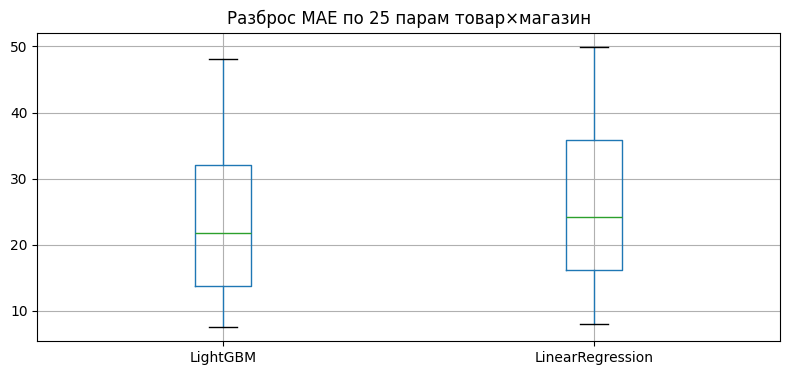

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
results_df.boxplot(column="MAE", by="model", ax=ax)
ax.set_title("Разброс MAE по 25 парам товар×магазин")
ax.set_xlabel("")
plt.suptitle("")
plt.tight_layout()
plt.show()


## Выводы

- Пайплайн (train/test split по времени + подбор гиперпараметров LightGBM через
  `RandomizedSearchCV` с `TimeSeriesSplit`) прогнан по всем 25 парам товар×магазин,
  а не на одном случайно выбранном SKU.
- Сравнение средних MAE/RMSE/MAPE/R² по всем парам — более надёжная оценка превосходства
  LightGBM над линейной регрессией, чем единичный пример.
- Разбивка по товарам в таблице выше показывает, для каких товаров выигрыш LightGBM больше —
  если он стабильно положителен почти везде, стоит рассмотреть перенос подобранных по умолчанию
  гиперпараметров в `fit_lightgbm_sales_model` (`model/pricing.py`); если выигрыш скачет от
  товара к товару — возможно, разумнее подбирать гиперпараметры отдельно для каждой группы
  товаров (например, по эластичности), а не использовать одни параметры на всё.
- Колонка `std` в сводной таблице показывает разброс качества между SKU: чем он больше,
  тем менее надёжно одно "среднее" число описывает реальную картину, и тем важнее смотреть
  на разбивку по товарам, а не только на агрегат.
